# Quickstart

## Packages

In [1]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import plotnine as pn
import decoupler as dc
import numpy as np
from scipy.spatial.distance import cdist

import partipy as pt
from partipy.datasets import load_hepatocyte_data_2

import matplotlib.pyplot as plt

plt.style.use("dark_background")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


ImportError: cannot import name 'plot_archetypes_2D' from 'partipy.plotting' (/Users/pschafer/Projects/ParTIpy/partipy/plotting.py)

In [5]:
x = 2.5

isinstance(x, str | int | float)

True

Note: Importing `partipy` for the first time after installing might take some time (~30s) because `numba` needs to compile some code in the background. After that, it'll be quick!

## Data

First, we need to load/download some single-cell data. Here, we will use mouse hepatocyte profiled by scRNA-seq from {cite:p}`benMoshe2022`.

In [2]:
adata = load_hepatocyte_data_2()
adata

AnnData object with n_obs × n_vars = 1999 × 8354
    obs: 'cell_type', 'zone', 'run_id', 'time_point', 'UMAP_X', 'UMAP_Y'

## Preprocessing

Before conducting archetypal analysis (AA) on single-cell RNA-seq data, it is benefical to reduce the dimensionality of the data. To achieve this, we first scale the counts across all cells to a common value, followed by log normalization. Next, we identify highly variable genes and then apply principal component analysis using only those highly variable genes. We use `scanpy` for all these steps.

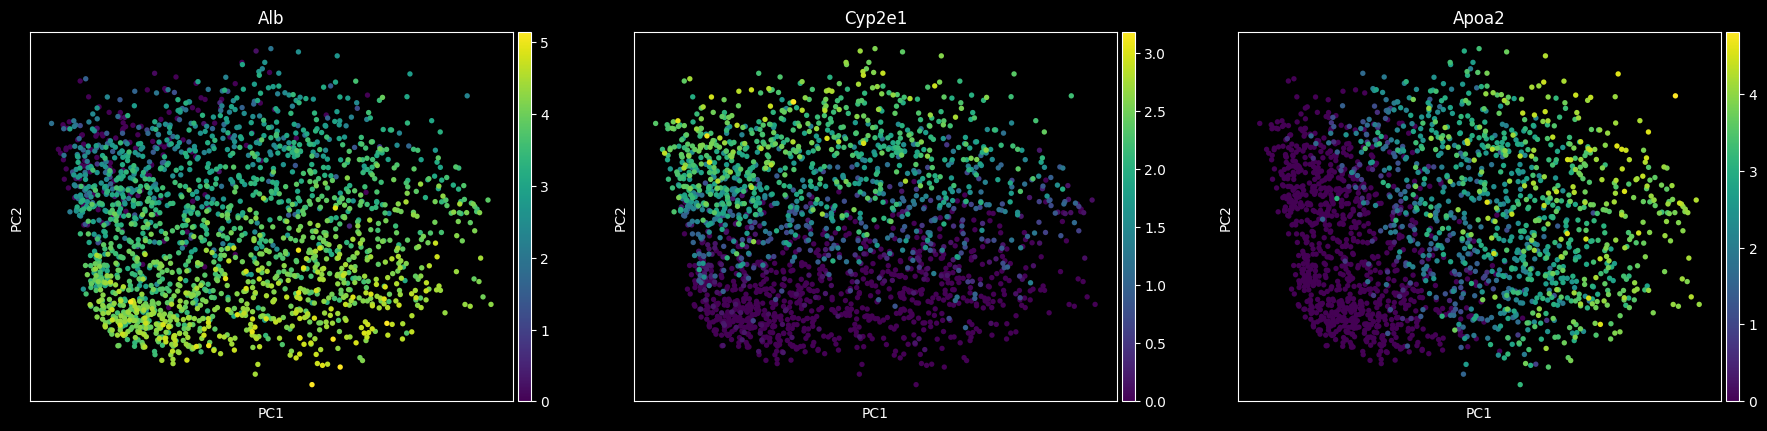

In [3]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pp.pca(adata, mask_var="highly_variable")
adata.layers["z_scaled"]= sc.pp.scale(adata.X, max_value=10, copy=True)
sc.pl.pca_scatter(adata, color=["Alb", "Cyp2e1", "Apoa2"])

To determine the number of principal components to use for fitting the archetypes, we will examine the scree plot from the PCA. Additionally the plot shows the variance explained if we shuffle the data before computing the PCA. This plot indicates that we should only use the first three principal components.

100%|██████████| 50/50 [00:04<00:00, 12.16it/s]


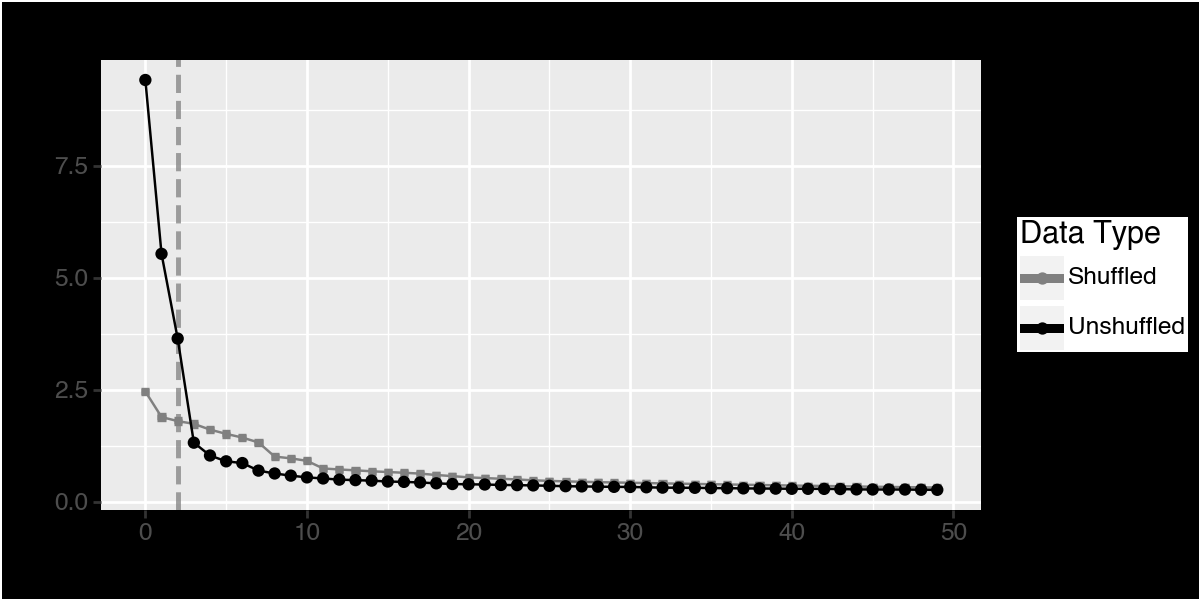

In [4]:
pt.compute_shuffled_pca(adata, mask_var="highly_variable")
pt.plot_shuffled_pca(adata)

We store this setting in the adata.uns slot using the utility function `set_obsm`. Using `n_dimensions=3` is equivalent to specifiy `n_dimensions=[0, 1, 2]`. If you do not want to use the first princial component, for example because it captures some technical effect, then you can simply specify `n_dimensions=[1, 2]`.

In [5]:
pt.set_obsm(adata=adata, obsm_key="X_pca", n_dimensions=3)

In [6]:
pt.compute_selection_metrics(adata)

In [11]:
pt.compute_bootstrap_variance(adata, n_bootstrap=10)
pt.compute_bootstrap_variance(adata, n_bootstrap=10, delta=0.5)

In [8]:
pt.get_aa_result(adata, n_archetypes=5)["Z"]

array([[-3.5257769 , -3.1651714 ,  1.2536185 ],
       [-4.617796  ,  4.3273425 , -0.65587497],
       [ 7.0734835 ,  1.082405  ,  3.4285924 ],
       [ 3.4316397 , -4.518332  , -4.5971437 ],
       [ 3.9348032 ,  4.9955173 , -3.5663824 ]], dtype=float32)

In [ ]:
pt.compute_bootstrap_variance(adata, n_bootstrap=10)

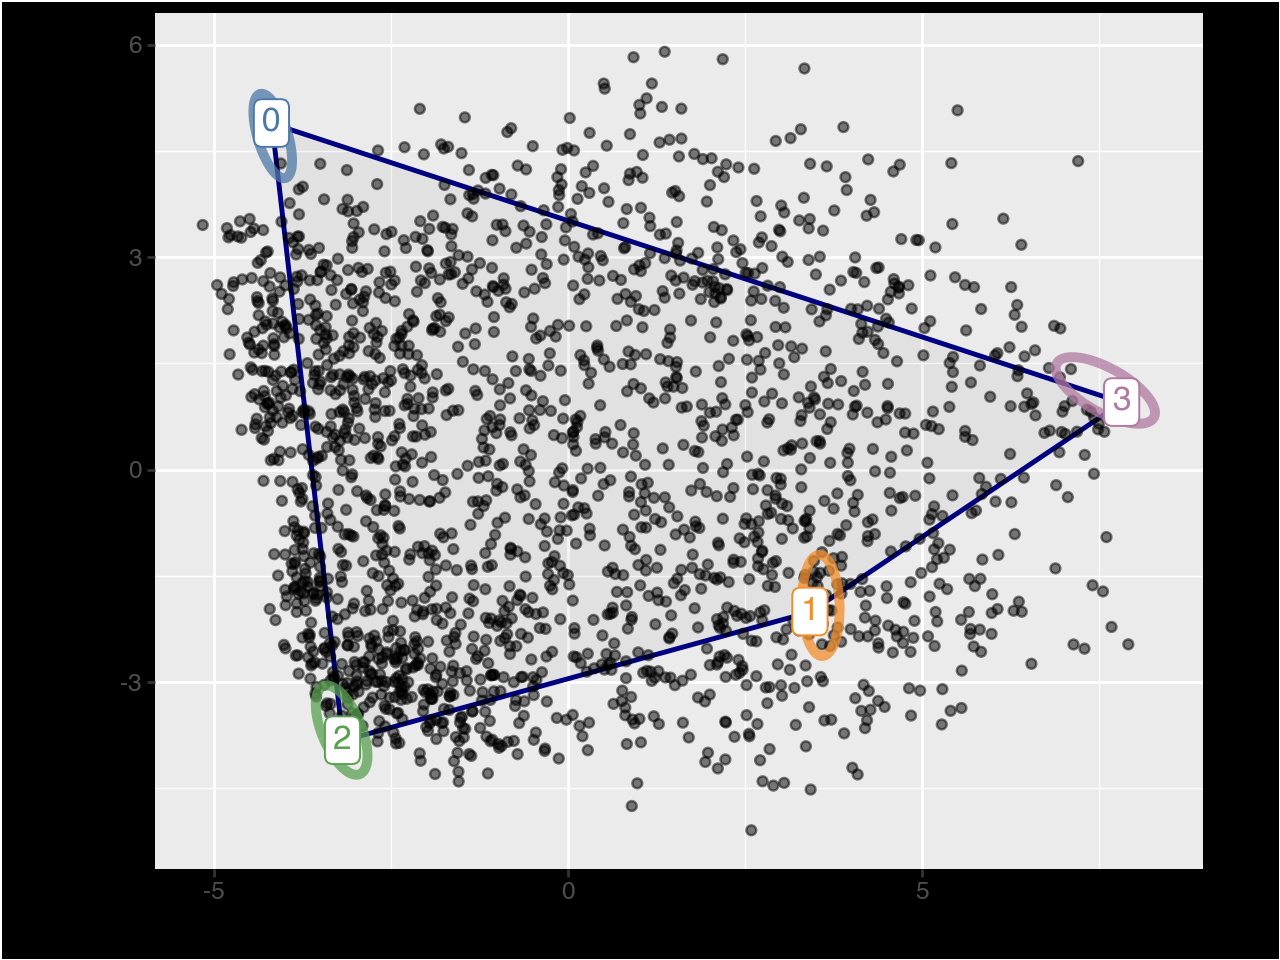

In [13]:
pt.plot_archetypes_2D(adata, result_filters={"n_archetypes": 4, "delta": 0.0}, show_contours=True)

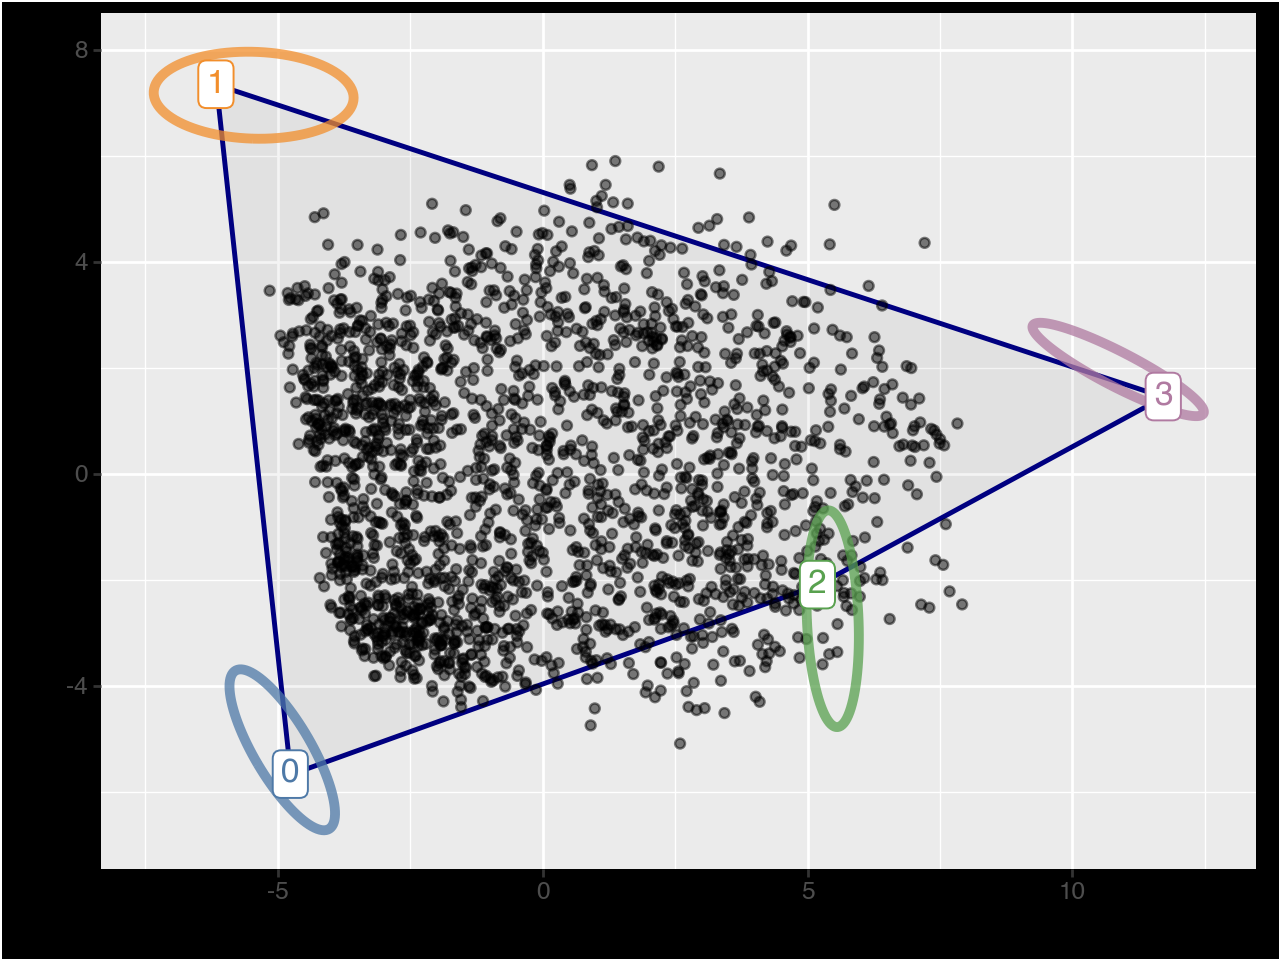

In [14]:
pt.plot_archetypes_2D(adata, result_filters={"n_archetypes": 4, "delta": 0.5}, show_contours=True)

In [ ]:
adata.uns["AA_metrics_df"]

In [ ]:
adata.uns["AA_results"]

In [ ]:
pt.compute_selection_metrics(adata)

In [ ]:
adata.uns["AA_metrics_df"]

In [ ]:
pt.compute_bootstrap_variance(adata, n_bootstrap=10, delta=0.5)

In [ ]:
pt.compute_bootstrap_variance(adata, n_bootstrap=10)

In [ ]:
pt.compute_archetypes(adata, n_archetypes=5, archetypes_only=False, delta=0.0, verbose=True)

In [ ]:
pt.compute_archetypes(adata, n_archetypes=6, archetypes_only=False, delta=0.0, verbose=True)

In [ ]:
pt.get_aa_result(adata, delta=0.0, n_archetypes=5)

In [ ]:
pt.compute_archetypes(adata, n_archetypes=4, archetypes_only=False, delta=0.0)
pt.compute_archetypes(adata, n_archetypes=4, archetypes_only=False, delta=0.5)

In [ ]:
#pt.get_aa_result(adata, delta=0.1)

In [ ]:
pt.compute_archetypes(adata, n_archetypes=6, archetypes_only=False, delta=0.0, verbose=True)

In [ ]:
import colorsys
from collections.abc import Mapping
from typing import Any

import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotnine as pn
import scanpy as sc
from matplotlib import ticker
from mizani.palettes import hue_pal
from scipy.spatial import ConvexHull, QhullError
from scipy.stats import chi2

from partipy._docs import docs
from partipy.paretoti import _validate_aa_config, _validate_aa_results, compute_selection_metrics, get_aa_result


def plot_archetypes_3D(
    adata: anndata.AnnData,
    dimensions: list[int] | None = None,
    show_contours: bool = False,
    contours_confidence_level: float = 0.95,
    contours_alpha: float = 0.3,
    color: str | None = None,
    size: float = 2.0,
    alpha: float = 0.2,
    alpha_hull: float = 0.2,
    aa_filter: Mapping[str, Any] | None = None,
) -> pn.ggplot:
    """
    Create an interactive 3D scatter plot showing data points, archetypes and the polytope they span.

    This function uses the first three principal components from `adata.obsm["X_pca"]`
    and visualizes the archetypes stored in `adata.uns["AA_results"]["Z"]`.
    If a color key is provided, it colors data points by the corresponding values from `adata.obs`.

    Parameters
    ----------
    adata : anndata.AnnData
        Annotated data object containing the PCA-reduced data in `obsm["X_pca"]` and
        archetypes in `uns["AA_results"]["Z"]`.
    color : str, default `None`
        Name of a column in `adata.obs` to color the data points by.
    size : int, default `2`
        The size of the markers for the data points in `X`.
    alpha : float, default `0.2`
        Opacity of the points in the scatter plot (0.0 to 1.0).
    alpha_hull : float, default `0.2`
        Opacity of the polytope spanned by the archetypes (0.0 to 1.0).

    Returns
    -------
    go.Figure
        A Plotly figure object showing a 3D scatter plot of the data and archetypes.
    """
    color_polyhedron = "#000080"
    color_points = "#000000"

    _validate_aa_config(adata)
    _validate_aa_results(adata)

    # --- Resolve the AA result using the fuzzy accessor ---------------------
    # Expects you defined: get_aa_result(adata, return_config=True, **filters)
    filters = dict(aa_filter or {})
    cfg, payload = get_aa_result(adata, return_config=True, **filters)  # type: ignore[name-defined]

    # Prefer fields from the matched config if present; otherwise fall back
    obsm_key = getattr(cfg, "obsm_key", adata.uns["AA_config"]["obsm_key"])
    cfg_dims = tuple(getattr(cfg, "n_dimensions", tuple(adata.uns["AA_config"]["n_dimensions"])))

    Z = payload.get("Z", None)
    if Z is None:
        raise ValueError("Matched AA payload does not contain 'Z'.")

    # --- Choose 3D coordinates ----------------------------------------------
    if dimensions is None:
        if len(cfg_dims) < 3:
            raise ValueError("Need at least three dimensions available to plot in 3D.")
        dimensions = list(cfg_dims[:3])
    if len(dimensions) != 3:
        raise ValueError("dimensions must contain exactly 3 indices for 3D plotting.")

    if (contours_confidence_level >= 1) or (contours_confidence_level <= 0):
        raise ValueError("contours_confidence_level must be in the interval (0, 1)")

    # --- Optional contours from bootstrap -----------------------------------
    if show_contours:
        if cfg not in adata.uns["AA_bootstrap"].keys():
            raise ValueError(
                f"{cfg} not found in adata.uns['AA_bootstrap']. Available keys: {list(adata.uns['AA_bootstrap'].keys())}"
            )
        bootstrap_df = adata.uns["AA_bootstrap"][cfg].copy()
        contour_df = _compute_contour_df_3D(
            bootstrap_df=bootstrap_df,
            col_1=f"{obsm_key}_{dimensions[0]}",
            col_2=f"{obsm_key}_{dimensions[1]}",
            col_3=f"{obsm_key}_{dimensions[2]}",
            confidence_level=contours_confidence_level,
        )

    data_df = pd.DataFrame(
        {
            f"{obsm_key}_{dimensions[0]}": adata.obsm[obsm_key][:, dimensions[0]],
            f"{obsm_key}_{dimensions[1]}": adata.obsm[obsm_key][:, dimensions[1]],
            f"{obsm_key}_{dimensions[2]}": adata.obsm[obsm_key][:, dimensions[2]],
        }
    )
    if color is not None:
        color_vec = sc.get.obs_df(adata, color).values.flatten() if color else None
        data_df["color"] = np.array(color_vec)
    else:
        data_df["color"] = "uniform_color"

    arch_df = pd.DataFrame(
        {
            f"{obsm_key}_{dimensions[0]}": Z[:, dimensions[0]],
            f"{obsm_key}_{dimensions[1]}": Z[:, dimensions[1]],
            f"{obsm_key}_{dimensions[2]}": Z[:, dimensions[2]],
            "archetype": np.arange(Z.shape[0]),
        }
    )
    arch_df["archetype"] = pd.Categorical(arch_df["archetype"])

    # take care of the colors
    unique_archetypes = sorted(arch_df["archetype"].unique())
    if len(unique_archetypes) <= len(DEFAULT_ARCHETYPE_COLORS):
        color_discrete_map = DEFAULT_ARCHETYPE_COLORS
    else:
        palette = generate_distinct_colors(len(unique_archetypes))
        color_discrete_map = {arch: palette[i] for i, arch in enumerate(unique_archetypes)}

    # Create the 3D scatter plot
    if color is not None:
        fig = px.scatter_3d(
            data_df,
            x=f"{obsm_key}_{dimensions[0]}",
            y=f"{obsm_key}_{dimensions[1]}",
            z=f"{obsm_key}_{dimensions[2]}",
            title="",
            color="color",
            opacity=alpha,
        )
    else:
        fig = px.scatter_3d(
            data_df,
            x=f"{obsm_key}_{dimensions[0]}",
            y=f"{obsm_key}_{dimensions[1]}",
            z=f"{obsm_key}_{dimensions[2]}",
            title="",
            opacity=alpha,
            color="color",
            color_discrete_sequence=[color_points],
        )

    fig.update_traces(marker={"size": size})

    # Add archetypes to the plot
    archetype_labels = [f"Archetype {i}" for i in range(Z.shape[0])]
    archetype_colors = [color_discrete_map.get(i, color_polyhedron) for i in range(Z.shape[0])]
    fig.add_trace(
        go.Scatter3d(
            x=Z[:, 0],
            y=Z[:, 1],
            z=Z[:, 2],
            mode="markers",
            text=archetype_labels,
            marker={"size": 8, "color": archetype_colors, "symbol": "diamond"},
            hoverinfo="text",
            name="Archetypes",
        )
    )

    # Add the polytope (convex hull) if we have enough archetypes
    if Z.shape[0] > Z.shape[1]:
        try:
            hull = ConvexHull(Z)
            fig.add_trace(
                go.Mesh3d(
                    x=Z[:, 0],
                    y=Z[:, 1],
                    z=Z[:, 2],
                    i=hull.simplices[:, 0],
                    j=hull.simplices[:, 1],
                    k=hull.simplices[:, 2],
                    color=color_polyhedron,
                    opacity=alpha_hull,
                    name="Polytope",
                )
            )
        except QhullError as e:
            print(f"Warning: Could not create convex hull: {e}")

    # Add edges connecting archetypes (optional - you might want to make this configurable)
    for i in range(Z.shape[0]):
        for j in range(i + 1, Z.shape[0]):
            fig.add_trace(
                go.Scatter3d(
                    x=[Z[i, 0], Z[j, 0]],
                    y=[Z[i, 1], Z[j, 1]],
                    z=[Z[i, 2], Z[j, 2]],
                    mode="lines",
                    line={"color": color_polyhedron, "width": 2},
                    showlegend=False,
                    opacity=0.3,
                )
            )

    if show_contours:
        # create mesh surface for each archetype
        for arch_idx in contour_df["archetype"].unique():
            arch_contour = contour_df[contour_df["archetype"] == arch_idx]

            fig.add_trace(
                go.Mesh3d(
                    x=arch_contour[f"{obsm_key}_{dimensions[0]}"],
                    y=arch_contour[f"{obsm_key}_{dimensions[1]}"],
                    z=arch_contour[f"{obsm_key}_{dimensions[2]}"],
                    opacity=contours_alpha,
                    color=color_discrete_map[arch_idx],
                    name=f"Contour {arch_idx}",
                    showlegend=True,
                    alphahull=0,  # Creates convex hull
                    hoverinfo="skip",
                )
            )

    fig.update_layout(
        template="plotly_white",
        scene={
            "xaxis_title": f"{obsm_key}_{dimensions[0]}",
            "yaxis_title": f"{obsm_key}_{dimensions[1]}",
            "zaxis_title": f"{obsm_key}_{dimensions[2]}",
        },
    )

    return fig

def _compute_contour_df_3D(
    bootstrap_df: pd.DataFrame, col_1: str, col_2: str, col_3: str, confidence_level: float = 0.95
):
    chi2_val = chi2.ppf(confidence_level, df=3)  # 3 DOF for 3D

    # Create spherical coordinates for sampling points on unit sphere
    n_theta = 100  # azimuthal angle resolution
    n_phi = 50  # polar angle resolution

    theta = np.linspace(0, 2 * np.pi, n_theta)
    phi = np.linspace(0, np.pi, n_phi)

    # Create meshgrid for spherical coordinates
    THETA, PHI = np.meshgrid(theta, phi)

    # Convert to Cartesian coordinates on unit sphere
    x_sphere = np.sin(PHI) * np.cos(THETA)
    y_sphere = np.sin(PHI) * np.sin(THETA)
    z_sphere = np.cos(PHI)

    # Flatten to get list of points
    sphere_points = np.column_stack([x_sphere.flatten(), y_sphere.flatten(), z_sphere.flatten()])

    contour_df_list = []

    for arch_idx in bootstrap_df["archetype"].unique():
        arch_df = bootstrap_df.loc[bootstrap_df["archetype"] == arch_idx, :].copy()
        arch_mtx = arch_df[[col_1, col_2, col_3]].values

        arch_mean = arch_mtx.mean(axis=0)
        arch_cov = np.cov(arch_mtx, rowvar=False, bias=True)

        # Eigendecomposition of covariance matrix
        eigenvals, eigenvecs = np.linalg.eigh(arch_cov)

        # Scale by chi-square value and eigenvalues
        scaling_matrix = eigenvecs @ np.diag(np.sqrt(chi2_val * eigenvals))

        # Transform unit sphere points to ellipsoid
        ellipsoid_points = sphere_points @ scaling_matrix.T + arch_mean

        # Create dataframe for the contour surface
        contour_df_list.append(
            pd.DataFrame(
                {
                    col_1: ellipsoid_points[:, 0],
                    col_2: ellipsoid_points[:, 1],
                    col_3: ellipsoid_points[:, 2],
                    "archetype": arch_idx,
                }
            )
        )

    contour_df = pd.concat(contour_df_list)
    contour_df["archetype"] = pd.Categorical(contour_df["archetype"])
    return contour_df

DEFAULT_ARCHETYPE_COLORS = {
    0: "#4e79a7",  # muted blue
    1: "#f28e2b",  # warm amber-orange
    2: "#59a14f",  # medium green
    3: "#b07aa1",  # muted violet
    4: "#edc948",  # golden yellow
    5: "#9c755f",  # soft brown
    6: "#bab0ab",  # gray-taupe
    7: "#76b7b2",  # muted teal
}


In [ ]:
plot_archetypes_3D(adata=adata, aa_filter={"n_archetypes": 4, "delta": 0.5}, show_contours=True)

In [ ]:
plot_archetypes_3D(adata=adata, aa_filter={"n_archetypes": 4, "delta": 0.0}, show_contours=True)

In [ ]:
adata.uns["AA_config"]

## Choosing the Number of Archetypes

Now, we are ready to perform archetypal analysis, but the key question remains: how many archetypes should be used?

There is no definitive ground truth for this choice, but several heuristics can guide the decision. One approach is to evaluate how much variance is explained by different numbers of archetypes.

The function `var_explained_aa()` takes the reduced PCA data and computes the explained variance across a range of archetypes (from `min_k` to `max_k`). By default, this function utilizes all available CPU cores, as indicated by the `n_jobs` argument, which is set to `-1`.

Additionally the function `var_explained_aa()` computes an information criteria which was suggested by Suleman, A., 2017. Validation of archetypal analysis, in: 2017 IEEE International Conference on Fuzzy Systems (FUZZ-IEEE) pp. 1–6. https://doi.org/10.1109/FUZZ-IEEE.2017.8015385


The results are stored in `adata.uns["AA_metrics"]` and can be effectively visualized using plot_var_explained_aa(). The plot suggests that a reasonable choice for the number of archetypes is 4 as the additional explained variance becomes negligible beyond this point.

In [ ]:
pt.compute_selection_metrics(adata=adata, min_k=2, max_k=8)
pt.plot_var_explained(adata)

In [ ]:
from typing import Any, Literal

INIT_ALGS = Literal["uniform", "furthest_sum", "plus_plus"]

In [ ]:
from typing import get_args

"plus_plus" in get_args(INIT_ALGS)

In [ ]:
list(INIT_ALGS)

In [ ]:
pt.plot_IC(adata)

An important consideration is whether the positions of the archetypes remain stable for a given number of archetypes. To assess this, we apply bootstrapping and perform Archetypal Analysis (AA) on resampled datasets.

By default, this function utilizes all available CPU cores, as specified by the `n_jobs` argument, which is set to `-1`. The results are stored in `adata.uns["AA_bootstrap"]` and can be visualized using `pt.plot_bootstrap_variance(adata)`.

As hinted to above, this result also suggest that 4 archetypes are highly stable.

In [ ]:
pt.compute_bootstrap_variance(adata=adata, n_bootstrap=50, n_archetypes_list=range(2, 9))
pt.plot_bootstrap_variance(adata)

In [ ]:
pt.compute_archetypes(adata, n_archetypes=4, archetypes_only=False, delta=0.6)

## Archetypal Analysis

To compute the archetypes, we can simply use the `compute_archetypes` function. There are many optimization parameters which we describe in more detail in the vignette about [Archetypal Analysis](https://partipy.readthedocs.io/en/latest/notebooks/archetypal_analysis.html).

To get a feeling for the archetypes we might plot the polytope on first two dimensions. However, note that we actually fitted the polytope in a higher dimensional space.

In [ ]:
pt.compute_bootstrap_variance(adata=adata, n_bootstrap=50, n_archetypes_list=range(2, 9), delta=0.6)
pt.plot_bootstrap_variance(adata)

In [ ]:
pt.compute_archetypes(adata, n_archetypes=4, archetypes_only=False, delta=0.6)

#pt.plot_archetypes_2D(adata=adata, show_contours=True)

In [ ]:
adata

In [ ]:
del adata.uns["AA_bootstrap"]

In [ ]:
pt.plot_archetypes_2D(adata=adata)

In [ ]:
pt.schema.OPTIM_ALGS

In [ ]:
?pt.compute_archetypes

In [ ]:
from dataclasses import dataclass

@dataclass(frozen=True)
class FooConfig:
    init: str
    optim: str

test_config = FooConfig("bar", "buz")
test_config

ddict = {}
ddict[test_config] = "hey"
ddict

In [ ]:
adata.obsm[test_config] = adata.obsm["X_pca"].copy()

In [ ]:
test_config.__hash__()

In [ ]:
adata

In [ ]:
adata.obsm[FooConfig(init="bar", optim="buz")]

In [ ]:
?pt.compute_bootstrap_variance

In [ ]:
?pt.compute_selection_metrics

In [ ]:
adata.uns["AA_results"]

In [ ]:
from __future__ import annotations
from typing import Any, Mapping, Literal
from pydantic import BaseModel, Field, field_validator, model_validator, ConfigDict

def _freeze(value: Any) -> Any:
    """Recursively convert common containers to hashable, deterministic forms."""
    from collections.abc import Mapping, Sequence
    import numpy as np

    if value is None or isinstance(value, (int, float, str, bool)):
        return value
    if isinstance(value, np.generic):  # numpy scalars -> Python scalars
        return value.item()
    if isinstance(value, Mapping):
        return tuple(sorted((k, _freeze(v)) for k, v in value.items()))
    if isinstance(value, (set, frozenset)):
        return tuple(sorted(_freeze(v) for v in value))
    if isinstance(value, Sequence) and not isinstance(value, (str, bytes)):
        return tuple(_freeze(v) for v in value)
    return repr(value)  # conservative fallback

class ArchetypeConfig(BaseModel):
    # Make the model immutable & hashable
    model_config = ConfigDict(frozen=True)

    # Enumerate if you have a known set; else keep str
    init: str
    optim: str
    weight: str | None = None

    max_iter: int = Field(ge=1)
    early_stopping: bool = False
    rel_tol: float = Field(gt=0.0, lt=1.0)

    coreset_algorithm: Literal["uniform", "kmeans++", "herding"] | None = None
    coreset_fraction: float | None = Field(default=None, gt=0.0, le=1.0)
    coreset_size: int | None = Field(default=None, ge=1)

    delta: float = Field(gt=0.0)
    seed: int

    # Accept mapping, normalize to a frozen, sorted tuple during validation
    optim_kwargs: Mapping[str, Any] = Field(default_factory=dict)

    @field_validator("optim_kwargs")
    @classmethod
    def _freeze_optim_kwargs(cls, v: Mapping[str, Any]) -> tuple[tuple[str, Any], ...]:
        return tuple(sorted((k, _freeze(val)) for k, val in dict(v).items()))

    @model_validator(mode="after")
    def _check_coreset_exclusivity(self) -> "ArchetypeConfig":
        # Allow: neither set, or exactly one set. Disallow: both set.
        if self.coreset_fraction is not None and self.coreset_size is not None:
            raise ValueError("Set either `coreset_fraction` or `coreset_size`, not both.")
        return self

    # Optional: a stable, human-readable composite key
    def key(self) -> tuple:
        return (
            self.init,
            self.optim,
            self.weight,
            self.max_iter,
            self.early_stopping,
            self.rel_tol,
            self.coreset_algorithm,
            self.coreset_fraction,
            self.coreset_size,
            self.delta,
            self.seed,
            self.optim_kwargs,  # already frozen & sorted
        )

In [ ]:
cfg = ArchetypeConfig(
    init="kmeans++",
    optim="pgd",
    weight=None,
    max_iter=2000,
    early_stopping=True,
    rel_tol=1e-4,
    coreset_algorithm="kmeans++",
    coreset_fraction=0.2,
    coreset_size=None,
    delta=1e-6,
    seed=42,
    optim_kwargs={"step_size": 0.1, "momentum": 0.9},
)

# Hashable: can be used as a dict key
results: dict[ArchetypeConfig, object] = {}
results[cfg] = "result_payload"

In [ ]:
results

For a given $k$ we can also visually asses the bootstrap stability using `pt.plot_bootstrap_2D(adata)` for the first two principal components and `pt.plot_bootstrap_3D(adata)` for the first three.

Since Plotly does not render properly when exporting Jupyter notebooks, we will use only the 2D scatter plot here.

In [ ]:
#pt.plot_bootstrap_3D(adata, n_archetypes=4)
pt.plot_bootstrap_2D(adata, n_archetypes=4)

We can assess statistical significance by permuting the principal component (PC) coordinates and evaluating whether the polytope fit is worse on the permuted data than on the original data. To quantify the goodness of fit, we can use the residual sum of squares (RSS), which yields a p-value of 0.0 in this case. Alternatively, we can use the ratio between the volume of the convex hull of the archetypes and that of the data, and assess whether this ratio is closer to 1 for the original data than for the permuted data. In this case, the resulting p-value is 0.13.

In [ ]:
significance = pt.t_ratio_significance(adata)
significance

Below, we will focus on the archetype that is enriched in detoxification functions.

In [ ]:
arch_idx = 0

## Characterizing Archetypes

To better understand the archetypes, we aim to obtain the characteristic gene expression profile for each one.

We begin by computing the archetypal weights using the `compute_archetype_weights()` function, which assigns each cell a weight for each archetype based on its proximity to the archetype in the reduced space.

Next, we generate a the characteristic expression profile for each archetype using weighted averaging. This is achieved with the `compute_archetype_expression()` function, which aggregates expression data across cells according to their archetypal contributions.

To better illustrate this, we visualize the weights for archetype **0**  using the `plot_2D_adata()` function, highlighting the extent to which each cell is associated with it.

In [ ]:
pt.compute_archetype_weights(adata=adata, mode="automatic")
archetype_expression = pt.compute_archetype_expression(adata=adata, layer="z_scaled")

adata.obs[f"weights_archetype_{arch_idx}"] = adata.obsm["cell_weights"][:, arch_idx]
pt.plot_archetypes_2D(adata=adata, color=f"weights_archetype_{arch_idx}")

Now we can use the characteristic gene expression profile to see which genes are relatively important for each archetype. As promised above, archetype 0 is characterized by high expression of Cytochrome P450 enzymes which are important for detoxification.

In [ ]:
archetype_expression.T.sort_values(arch_idx, ascending=False).head(10)

We can also use the characteristic gene expression profiles of each archetype to perform enrichment analysis with decoupler. Here, we focus on Reactome pathways because we are interested in metabolic processes.

In [ ]:
database = "reactome_pathways"
min_genes_per_pathway = 5
max_genes_per_pathway = 80

# dc.op.resource("SIGNOR", organism="mouse")
msigdb_raw = dc.op.resource("MSigDB")
msigdb = msigdb_raw[msigdb_raw["collection"]==database]
selection_vec = ~ np.array(["RESPONSE_TO" in s for s in msigdb["geneset"]]) & \
    ~ np.array(["GENE_EXPRESSION" in s for s in msigdb["geneset"]]) & \
    ~ np.array(["SARS_COV" in s for s in msigdb["geneset"]]) & \
    ~ np.array(["STIMULATED_TRANSCRIPTION" in s for s in msigdb["geneset"]])
msigdb = msigdb.loc[selection_vec, :].copy()
msigdb = msigdb[~msigdb.duplicated(["geneset", "genesymbol"])].copy()
genesets_within_min = (msigdb.value_counts("geneset") >= min_genes_per_pathway).reset_index().query("count")["geneset"].to_list()
genesets_within_max = (msigdb.value_counts("geneset") <= max_genes_per_pathway).reset_index().query("count")["geneset"].to_list()
genesets_to_keep = list(set(genesets_within_min) & set(genesets_within_max))
msigdb = msigdb.loc[msigdb["geneset"].isin(genesets_to_keep), :].copy() # removing small gene sets
msigdb = msigdb.rename(columns={"geneset": "source", "genesymbol": "target"}) # required since decoupler >= 2.0.0
msigdb_mouse = dc.op.translate(msigdb, target_organism="mouse", columns=["target"]) # requires decoupler >= 2.0.0
msigdb_mouse = msigdb_mouse.drop_duplicates()

acts_ulm_est, acts_ulm_est_p = dc.mt.ulm(data=archetype_expression,
                                         net=msigdb_mouse,
                                         verbose=False)

acts_ulm_est.iloc[:4, :4]

We can then extract the top $x$ (here $x=10$) processes per archetype using 
`extract_enriched_processes()`. Focusing on Archetype 0 this revals Reactome pathways related to xenobiotics (including pathways related to oxidiaton and functionalization).

In [ ]:
top_processes = pt.extract_enriched_processes(est=acts_ulm_est, 
                                              pval=acts_ulm_est_p, 
                                              order="desc", 
                                              n=10,
                                              p_threshold=0.05)
top_processes[0]

In [ ]:
top_processes[arch_idx]["Process"] = pd.Categorical(
    top_processes[arch_idx]["Process"],
    categories=top_processes[arch_idx].sort_values(f"{arch_idx}", ascending=True)["Process"].to_list()
)

(pn.ggplot(top_processes[arch_idx])
 + pn.geom_col(pn.aes(x="Process", y=f"{arch_idx}"))
 + pn.coord_flip()
 + pn.theme(figure_size=(10, 3)))

Then, we can decoupler's leading edge function to check for example which genes have a high weight for our archetype of interest, and are in the gene set for "REACTOME_XENOBIOTICS".

In [ ]:
df = archetype_expression.T.copy()
df.columns = df.columns.astype(str)
_, le = dc.pl.leading_edge(
    df = df,
    net = msigdb_mouse,
    stat = str(arch_idx),
    name = "REACTOME_XENOBIOTICS"
)
print(le)

Another interesting thing we can do is to consider how gene expressions changes as a function of the distance to some archetype. To this end we can use the decoupler functions `dc.tl.rankby_order`, `dc.pp.bin_order`, and `dc.pl.order`.

In [ ]:
distances = cdist(
    adata.obsm[adata.uns["AA_config"]["obsm_key"]][:, adata.uns["AA_config"]["n_dimensions"]],
    adata.uns["AA_results"]["Z"]
)
for idx in range(adata.uns["AA_results"]["Z"].shape[1]):
    adata.obs[f"dist_to_arch_{idx}"] = distances[:, idx]

genes_ordered = dc.tl.rankby_order(
    adata=adata,
    order=f"dist_to_arch_{arch_idx}",
    stat="spearmanr",
)
top_genes = genes_ordered.sort_values("stat").head(8)["name"].to_list()
bottom_genes = genes_ordered.sort_values("stat").tail(8)["name"].to_list()

top_genes_ordered = dc.pp.bin_order(
    adata=adata,
    order=f"dist_to_arch_{arch_idx}",
    names=top_genes,
     nbins=50,
)

bottom_genes_ordered = dc.pp.bin_order(
    adata=adata,
    order=f"dist_to_arch_{arch_idx}",
    names=bottom_genes,
     nbins=50,
)

dc.pl.order(
    df=top_genes_ordered,
    mode="line",
    figsize=(6, 3),
)

dc.pl.order(
    df=bottom_genes_ordered,
    mode="line",
    figsize=(6, 3),
)

## Spatial Enrichment

As in {cite:p}`Adler2019`, we want to quantify where the archetypes locate in the tissue.

To that end we download a single-cell spatial data set from the liver from https://info.vizgen.com/mouse-liver-data (Vizgen MERFISH Mouse Liver Map January 2022). In particular we only need to download from `Liver1Slice1` the files `"cell_by_gene.csv", "cell_metadata.csv"` and place those in the folder `Liver1Slice1` in `data`.

Then, to quantify to which archetype any given cell is close to, we compute the enrichment of the archetype gene expression signatures in each cells' gene expression profile.

In [ ]:
import sys
!{sys.executable} -m pip install --quiet squidpy

In [ ]:
archetype_expression

In [ ]:
# only run if the data has actually been downloaded
if (Path(".") / "data" / "Liver1Slice1" / "Liver1Slice1_cell_by_gene.csv").exists() and (Path(".") / "data" / "Liver1Slice1" / "Liver1Slice1_cell_metadata.csv").exists():
    import squidpy as sq
    vizgen_adata = sq.read.vizgen(
        "./data/Liver1Slice1",
        counts_file="Liver1Slice1_cell_by_gene.csv",
        meta_file="Liver1Slice1_cell_metadata.csv",
    )
    vizgen_adata = vizgen_adata[:, vizgen_adata.var.index.isin(archetype_expression.columns.to_list())].copy()
    vizgen_adata = vizgen_adata[vizgen_adata.X.sum(axis=1).A1 > 200, :].copy()
    sc.pp.normalize_total(vizgen_adata)
    sc.pp.log1p(vizgen_adata)

    # create weights based on archetype expression profile
    archetype_expression_weights = (archetype_expression[vizgen_adata.var.index].copy()
                                    .reset_index(names="archetype")
                                    .melt(id_vars="archetype", value_name="weight", var_name="gene")
                                    )
    archetype_expression_weights = archetype_expression_weights.rename(columns={"archetype": "source", "gene": "target"})

    # compute the enrichment of the archetype gex profiles in the gex profiles of each cell
    dc.mt.ulm(data=vizgen_adata, net=archetype_expression_weights, verbose=False)

    # plotting one part
    plotting_df = vizgen_adata.obsm["score_ulm"].copy()
    plotting_df.columns = ["archetype_" + idx for idx in plotting_df.columns]
    plotting_df = plotting_df - plotting_df.mean()
    plotting_df = plotting_df / plotting_df.std()
    plotting_df["x"] = vizgen_adata.obsm["spatial"][:, 0]
    plotting_df["y"] = vizgen_adata.obsm["spatial"][:, 1]

    width = 3_000
    x_low = 5_000
    y_low = 6_000
    x_high = x_low + width
    y_high = y_low + width
    plotting_df = plotting_df.loc[(plotting_df["x"] > x_low) & (plotting_df["x"] < x_high) & (plotting_df["y"] > y_low) & (plotting_df["y"] < y_high)]

    plotting_df = plotting_df.melt(id_vars=["x", "y"], value_name="score", var_name="archetype")
    p = (pn.ggplot(plotting_df) 
        + pn.geom_point(pn.aes(x="x", y="y", color="score"), size=0.1, alpha=0.5) 
        + pn.scale_color_gradient2(low="blue", mid="white", high="red", midpoint=0)
        + pn.facet_wrap(facets="archetype", nrow=2, ncol=2)
        + pn.coord_equal() 
        + pn.theme(figure_size=(8, 8)) 
        + pn.labs(x="x", y="y", color="Activity")
        )
    p.show()

## Session Info

In [ ]:
import session_info2
print(session_info2.session_info(dependencies=True))